<a href="https://colab.research.google.com/github/Sr-santi/seq2seq_electric_curves_reconstruction/blob/master/customer_electricity_consumption_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seq2Seq Challenge

Given the challenge inside [Challenge Data](https://challengedata.ens.fr/challenges/160), we will have a set of synthetic data that represents the consumption of multiple users, where 1000 of these consumption curves contain random data removal, The goal of that challenge is to propose replacements for missing values (“fill the holes”) in the 1000 curves.

Steps to consider:
1. We are going to read the data and separate the holed curves
2. We are going to train our model with the curves that are complete and train and evaluate the model with these data
3. later we will test the results with the testing data and if everything looks good, we are going to propose the values for the holed curves
4. We can consider some metrics to check how accurate is our model and the predictions


# Preparing and understanding my dataset

TODOs:

1. Organize the data analysis sections to show a clear process of why we are normalizing the data , how is our data distribution and make it clear the go throught of the data that we are using
2. Make each section interconnected to show a clear understanding of the step by step process here

## Data Loading

In [1]:
# reading data

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import time
import math
import matplotlib.pyplot as plt
import os

# --- Environment Detection & Setup ---
try:
    # This will succeed only in Colab
    from google.colab import drive
    print("Running in Google Colab. Mounting Drive...")
    drive.mount('/content/drive')
    
    # Set the Colab data path
    DATA_DIR = "/content/drive/MyDrive/energy_consumption_challenge/"
    SAVE_DIR = "/content/drive/MyDrive/energy_consumption_challenge/"
    
except ImportError:
    # This block executes if you are running locally
    print("Running locally. Using local data directory...")
    
    # Set the local data path (e.g., the 'data' folder we discussed earlier)
    DATA_DIR = "./data/"
    SAVE_DIR = "./checkpoints/"
    
    # Make sure the local save directory exists
    os.makedirs(SAVE_DIR, exist_ok=True)

Running locally. Using local data directory...


In [2]:
# How many cores are available?
os.cpu_count()

12

In [3]:
import pandas as pd

# Load the data
x_test_data = pd.read_csv(f"{DATA_DIR}/X_test_XKVc4no.csv", index_col=0, parse_dates=True)
y_train_data = pd.read_csv(f"{DATA_DIR}/y_train_u0UkKEh.csv", index_col=0, parse_dates=True)
x_train_data = pd.read_csv(f"{DATA_DIR}/X_train_78VdSWL.csv", index_col=0, parse_dates=True)

In [4]:
import random
import os
import numpy as np
import torch

def set_seed(seed=42):
    """
    Sets the seed for reproducibility across random, numpy, and torch.
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Configure CuDNN for deterministic behavior
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Tell PyTorch to use Tensor Cores for massive speedups on our RTX 3060
    torch.set_float32_matmul_precision('medium') 
    # torch.set_float32_matmul_precision('high')

    print(f"Global seed set to: {seed}")

# Initialize the environment with a fixed seed
set_seed(42)

Global seed set to: 42


In [ ]:
from sklearn.model_selection import train_test_split

def analyze_cols(df):
    cols = df.columns.tolist()
    holed = [c for c in cols if 'holed' in c.lower()]
    # Since index_col=0 was used, all current columns are either 'holed' or 'normal'
    normal = [c for c in cols if 'holed' not in c.lower()]
    return len(holed), len(normal), holed, normal

# Get stats using the full DataFrames
h_xtrain, n_xtrain, x_train_holed_cols, x_train_normal_cols  = analyze_cols(x_train_data)
h_xtest, n_xtest, x_test_holed_cols, x_test_normal_cols = analyze_cols(x_test_data)
# y_train_data contains the answers for the x_train_data dataset
h_ytrain, n_ytrain = (0, y_train_data.shape[1])


# Create the actual DataFrames
# the holed columns are the same inside train and test in this case
# we have some redundancy in the data
df_train_holed = x_train_data[x_train_holed_cols]
df_train_normal = x_train_data[x_train_normal_cols]

df_test_normal = x_test_data[x_test_normal_cols]

# remove columns with NaN values in train and test files
df_train_normal = df_train_normal.dropna(axis=1)
df_test_normal = df_test_normal.dropna(axis=1)

# combined dataset
df_normal_all = pd.concat([df_train_normal, df_test_normal], axis=1)

# Split into Train (80%) and Validation (20%)
# We split by column (Meter ID) so the model learns from different buildings
train_ids, val_ids = train_test_split(df_normal_all.columns, test_size=0.2, random_state=42)

# -----------------------------------------



# Build the Summary Structure
summary_df = pd.DataFrame({
    "Total Rows": [x_train_data.shape[0], y_train_data.shape[0], x_test_data.shape[0]],
    "Total Columns": [x_train_data.shape[1], y_train_data.shape[1], x_test_data.shape[1]],
    "Holed Columns": [h_xtrain, h_ytrain, h_xtest],
    "Normal Columns": [n_xtrain, n_ytrain, n_xtest]
}, index=["X_train", "y_train", "X_test"])

print("--- Dataset Column Summary ---")
print(summary_df)

--- Dataset Column Summary ---
         Total Rows  Total Columns  Holed Columns  Normal Columns
X_train        1057          21000           1000           20000
y_train        1057           1000              0            1000
X_test         1057          38140           1000           37140


In [5]:
print(f"Train Date Range: {df_train_holed.index.min()} to {df_train_holed.index.max()}")
# we have data from 01-09 to 01-31
# We can divide the data in smaller time windows and ranges to manage it better and train de model
# Sampling is every 30 min

Train Date Range: 2023-01-09 00:00:00 to 2023-01-31 00:00:00


## Holed curves considerations

For the 1000 curves that we need to fix, we want to know how our data is composed by trying to understand what is behavior or the data that is not registered in order to determinate what is the best strategy for the model training setup and data reconstruction.

1. First we are going to check an overall picture of the missing data to later make an analysis of the missing data composition
2. For the analisys; We want to know how long are the consecutive missing points, the distribution of the missing points and how they are distributed along the consumption curves
3. After consider the previous information we will conclude some consideration and details to consider during our training step

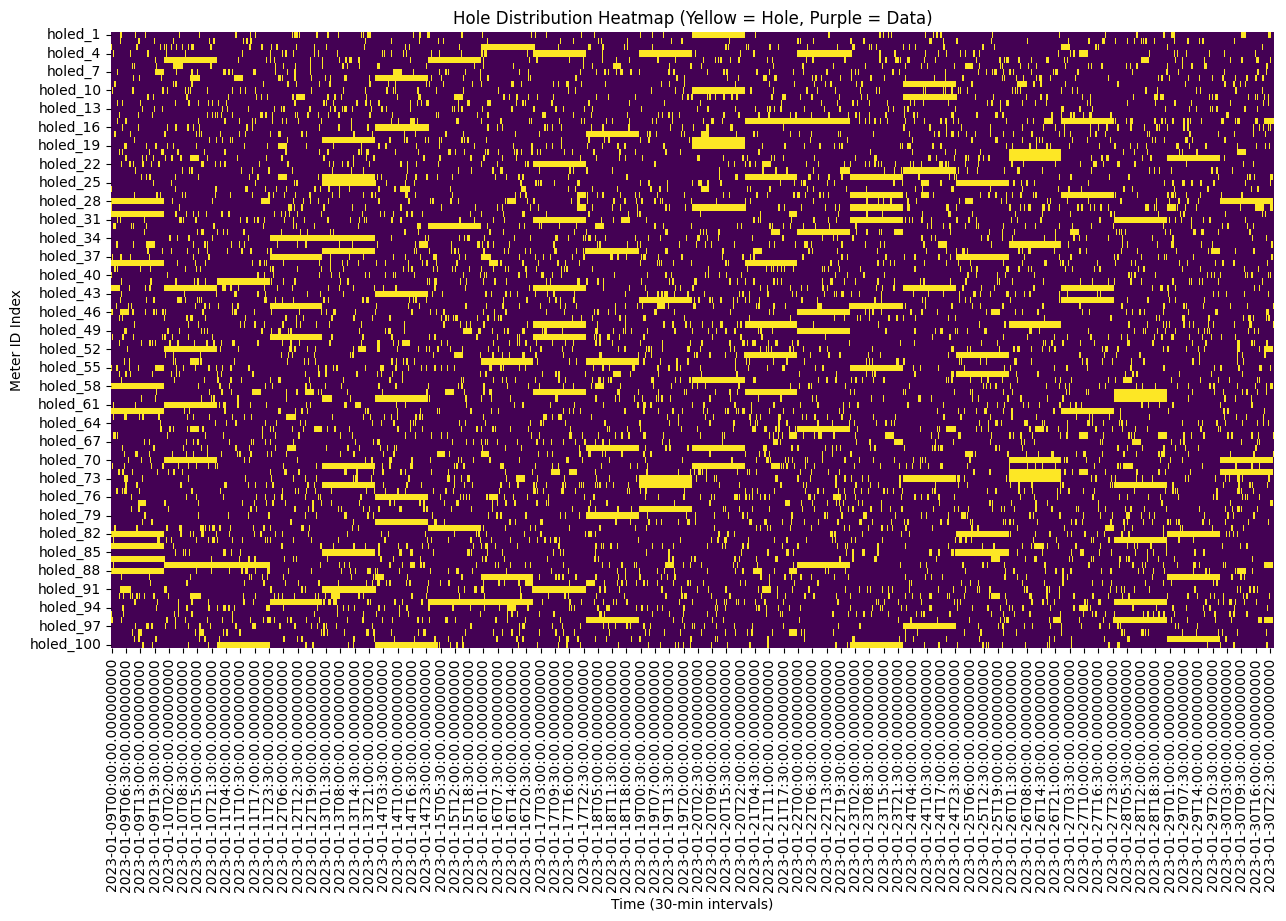

In [ ]:
# Overall picture of the missing data using a heat map
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_hole_distribution(df_holed):
    """
    df_holed: The 1,000 meters with gaps.
    Identifies where zeros/NaNs are located across the month.
    """
    # Create a binary mask of where the 'holes' are (0 or NaN)
    # Adjust the condition if you think some 0s are valid consumption
    # hole_mask = (df_holed == 0) | (df_holed.isna())
    hole_mask = (df_holed.isna())

    plt.figure(figsize=(15, 8))
    # Plotting a subset (e.g., first 100 meters) to see the temporal distribution
    sns.heatmap(hole_mask.iloc[:, :100].T, cbar=False, cmap='viridis')
    plt.title("Hole Distribution Heatmap (Yellow = Hole, Purple = Data)")
    plt.xlabel("Time (30-min intervals)")
    plt.ylabel("Meter ID Index")
    plt.show()

    # Calculate gap lengths
    gap_lengths = hole_mask.astype(int).cumsum()
    # (Optional: Add logic here to histogram the lengths of consecutive zeros)

analyze_hole_distribution(df_train_holed)

--- Verification for holed_4 ---
Number of holes found in X_train: 207

y_train distribution for holed_4:
count    1057.000000
mean      131.353832
std       235.907929
min         0.000000
25%         0.000000
50%         1.000000
75%       210.000000
max      1646.000000
Name: holed_4, dtype: float64
Max consecutive missing points: 180
Average gap length: 13.17 



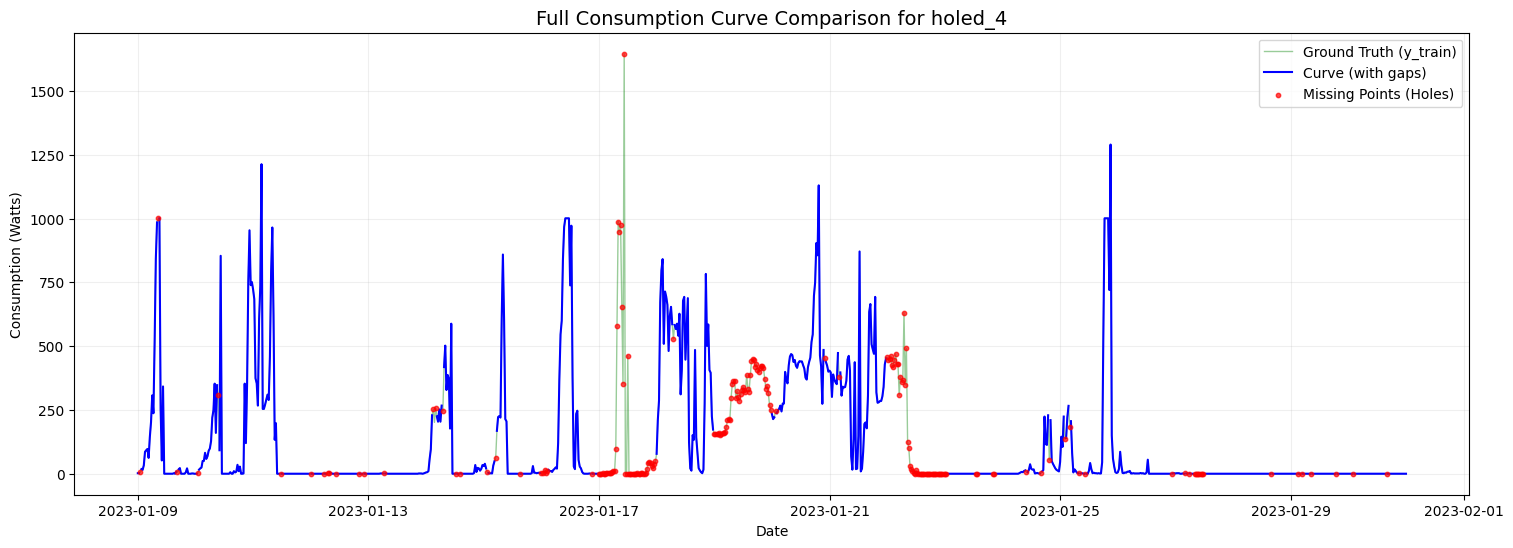

In [ ]:
# Here we are seeing the curve that we need to reconstruct compared with
# the curve that contains all the missing points
# This is an specific example to vizualize the problem
import numpy as np
import matplotlib.pyplot as plt

CURVE_INDEX = 3
# Let's check the first holed column
sample_col = x_train_holed_cols[CURVE_INDEX]

# Strategy: Find where X_train is NaN (where the data is removed), and see what y_train has there
# (Assuming holes are represented by NaN)
holes_mask = df_train_holed[sample_col].isna()

print(f"--- Verification for {sample_col} ---")
print(f"Number of holes found in X_train: {holes_mask.sum()}")

# Check distribution of values in y_train for that column
print(f"\ny_train distribution for {sample_col}:")
print(y_train_data[sample_col].describe())

# -------------------------------------------------------
# This tells us if holes are isolated or in big chunks
is_hole = (df_train_holed[sample_col] == 0) | (df_train_holed[sample_col].isna())
gap_lengths = is_hole.groupby((is_hole != is_hole.shift()).cumsum()).sum()
print(f"Max consecutive missing points: {gap_lengths.max()}")
print(f"Average gap length: {gap_lengths[gap_lengths > 0].mean():.2f} \n")

# -------------------------------------------------------
# 1. Plotting the WHOLE curve
plt.figure(figsize=(18, 6))

# Plot ground truth
plt.plot(y_train_data.index, y_train_data[sample_col], label='Ground Truth (y_train)', color='green', alpha=0.4, linewidth=1)

# Plot the data with holes (X_train) - we filter out the 0s to show the gaps
visible_data = df_train_holed[sample_col]
plt.plot(visible_data.index, visible_data, label='Curve (with gaps)', color='blue', linewidth=1.5)

# Highlight where the holes were (NaN values)
is_hole = df_train_holed[sample_col].isna()
plt.scatter(df_train_holed.index[is_hole], y_train_data[sample_col][is_hole],
            color='red', s=10, label='Missing Points (Holes)', alpha=0.7, zorder=5)

plt.title(f"Full Consumption Curve Comparison for {sample_col}", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Consumption (Watts)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

## Holed curves analysis

hole distribution analysis on the 1,000 holed consumption curves in `df_train_holed`.

Specifically:
1.  **Calculate Gap Metrics**: Identify sequences of missing data (NaNs) and calculate the length of every consecutive gap for all 1,000 meters.
2.  **Aggregate Statistics**: Compute global metrics including the mean gap length, median gap length, and the distribution of maximum gap sizes across all users.
3.  **Visualize Gap Distribution**: histogram howing the distribution of these gap lengths to determine if holes are typically short bursts or long-term outages.
4.  **Summary and Implications**: Summary of the findings and how these gap characteristics (e.g., long vs. short sequences) influence the Seq2Seq architecture or window size selection for the "fill the holes" problem.

The conclutions of this analysis:

**Gap Frequency and Scale**: A total of 55,966 gaps were identified across 1,000 meters. The distribution is heavily skewed toward very short sequences, with a global median and mode of 1.0 interval.

**Long-Term Outages**: Although long outages are rare (only 0.34% of gaps exceed 24 hours), they are significant. The 99th percentile of gap lengths is 48 intervals (24 hours), and the maximum recorded gap is 857 intervals (~18 days).

**Per-Meter Extremes**: On average, the maximum gap a single meter experiences is 38.29 intervals. At least 50% of the meters have encountered a gap of at least 24 hours (48 intervals).


Considerations for our setup:

These results indicates that while most gaps are single intervals, the 99th percentile reaches 48 intervals (24 hours). Consequently, a context window of at least 168 intervals (7 days) is recommended to capture weekly seasonality. The architecture should be an Encoder-Decoder (Seq2Seq) model that incorporates the grid_mean (Global Grid Pulse) as an external feature to provide a baseline for long-term outages (up to 857 intervals).

### Calculate Gap Metrics

calculate the gap lengths for all 1,000 holed meters by iterating through the columns of df_train_holed, identifying consecutive NaNs, and storing both individual gap lengths and the maximum gap per meter.

In [ ]:
all_gap_lengths = []
max_gaps_per_meter = {}

# Iterate through each holed meter (1000 columns)
for col in df_train_holed.columns:
    # Identify NaNs
    is_na = df_train_holed[col].isna()

    # Group consecutive NaNs and count their lengths
    # (is_na != is_na.shift()).cumsum() creates a new group ID every time the value changes from NaN to non-NaN or vice-versa
    gap_groups = is_na.groupby((is_na != is_na.shift()).cumsum())

    # Filter only groups that are NaNs and get their lengths
    # We use .sum() because 'is_na' is boolean (True=1, False=0)
    lengths = gap_groups.sum()
    lengths = lengths[lengths > 0].tolist()

    all_gap_lengths.extend(lengths)
    max_gaps_per_meter[col] = max(lengths) if lengths else 0

# Verification
num_meters_processed = len(max_gaps_per_meter)
print(f"Total meters processed: {num_meters_processed}")
print(f"Total number of gaps identified across all meters: {len(all_gap_lengths)}")
if len(all_gap_lengths) > 0:
    print(f"Global Maximum Gap Length: {max(all_gap_lengths)}")
    print(f"Global Average Gap Length: {np.mean(all_gap_lengths):.2f}")

# Store results for later use
global_gap_series = pd.Series(all_gap_lengths)

Total meters processed: 1000
Total number of gaps identified across all meters: 55966
Global Maximum Gap Length: 857
Global Average Gap Length: 2.32


### Aggregate Statistics

global and per-meter gap statistics, including percentiles and descriptive summaries, using the previously defined `global_gap_series` and `max_gaps_per_meter` to quantify the nature of missing data.


In [ ]:
import pandas as pd
import numpy as np

# 1. Global Gap Statistics
global_mean = global_gap_series.mean()
global_median = global_gap_series.median()
global_mode = global_gap_series.mode()[0]

# 2. Tail Distribution (Percentiles)
percentiles = [0.25, 0.75, 0.90, 0.95, 0.99]
gap_percentiles = global_gap_series.quantile(percentiles)

# 3. Per-Meter Max Gap Analysis
max_gaps_series = pd.Series(list(max_gaps_per_meter.values()))
max_gap_stats = max_gaps_series.describe(percentiles=[0.5, 0.75, 0.9])

# 4. Display Results
print("--- Global Gap Length Statistics ---")
print(f"Mean Gap Length:   {global_mean:.2f} (intervals)")
print(f"Median Gap Length: {global_median:.2f}")
print(f"Mode Gap Length:   {global_mode}")

print("\n--- Global Gap Percentiles ---")
for p, val in gap_percentiles.items():
    print(f"{int(p*100)}th Percentile: {val:.1f} intervals")

print("\n--- Statistics of Maximum Gaps per Meter ---")
print(max_gap_stats)

# Logic check for Seq2Seq
long_gaps_count = (global_gap_series > 48).sum()
print(f"\nTotal gaps longer than 24 hours (48 intervals): {long_gaps_count}")
print(f"Percentage of gaps that are long-term outages (24 hours): {(long_gaps_count/len(global_gap_series))*100:.2f}%")

--- Global Gap Length Statistics ---
Mean Gap Length:   2.32 (intervals)
Median Gap Length: 1.00
Mode Gap Length:   1

--- Global Gap Percentiles ---
25th Percentile: 1.0 intervals
75th Percentile: 1.0 intervals
90th Percentile: 2.0 intervals
95th Percentile: 3.0 intervals
99th Percentile: 48.0 intervals

--- Statistics of Maximum Gaps per Meter ---
count    1000.00000
mean       38.28600
std        34.82877
min         2.00000
50%        48.00000
75%        48.00000
90%        50.00000
max       857.00000
dtype: float64

Total gaps longer than 24 hours (48 intervals): 191
Percentage of gaps that are long-term outages (24 hours): 0.34%


### Visualize Gap Distribution


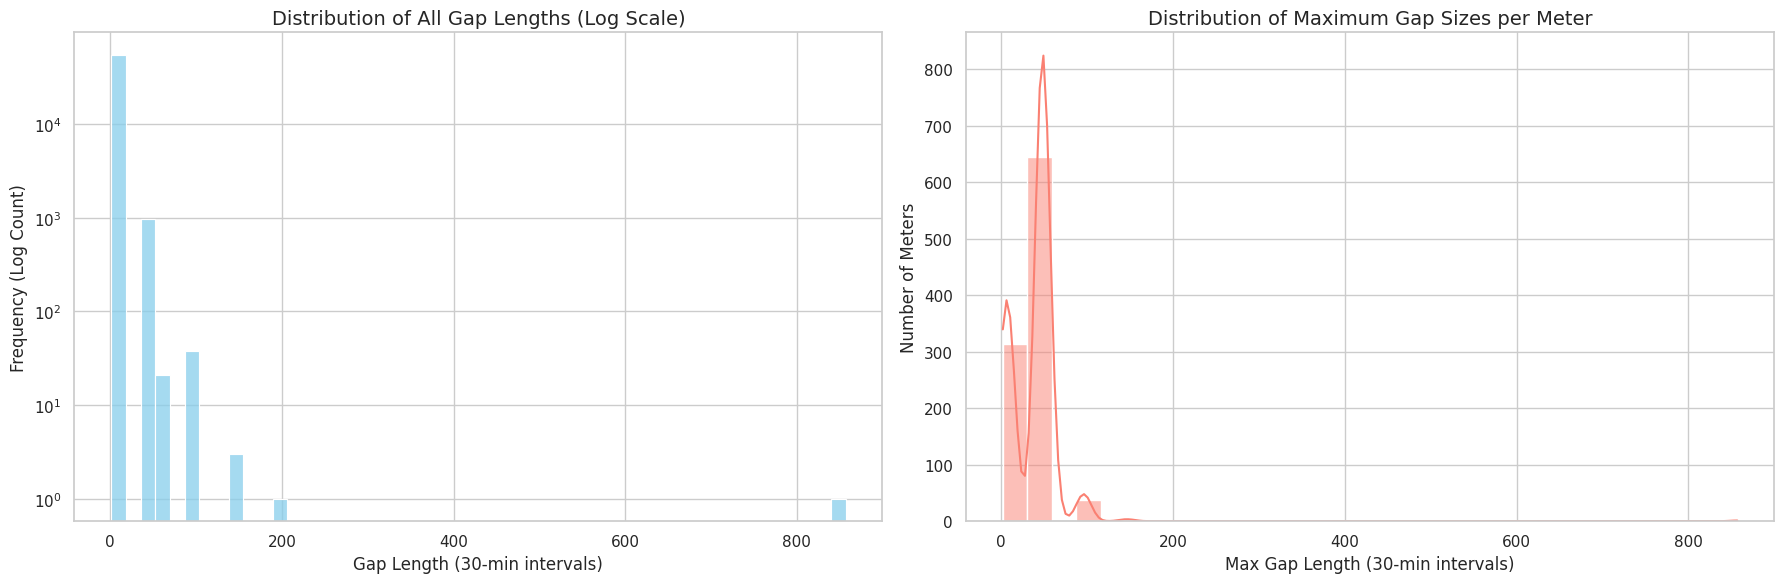

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style for the plots
sns.set_theme(style="whitegrid")

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# 1. Distribution of All Gap Lengths (Global)
sns.histplot(global_gap_series, bins=50, kde=False, color='skyblue', ax=ax1)
ax1.set_yscale('log')
ax1.set_title("Distribution of All Gap Lengths (Log Scale)", fontsize=14)
ax1.set_xlabel("Gap Length (30-min intervals)", fontsize=12)
ax1.set_ylabel("Frequency (Log Count)", fontsize=12)

# 2. Distribution of Maximum Gaps per Meter
sns.histplot(max_gaps_series, bins=30, kde=True, color='salmon', ax=ax2)
ax2.set_title("Distribution of Maximum Gap Sizes per Meter", fontsize=14)
ax2.set_xlabel("Max Gap Length (30-min intervals)", fontsize=12)
ax2.set_ylabel("Number of Meters", fontsize=12)

plt.tight_layout()
plt.show()

-----------------------------------------

## Data analysis

We will analyze our training data to know how is the distribution of the consumption along the training data


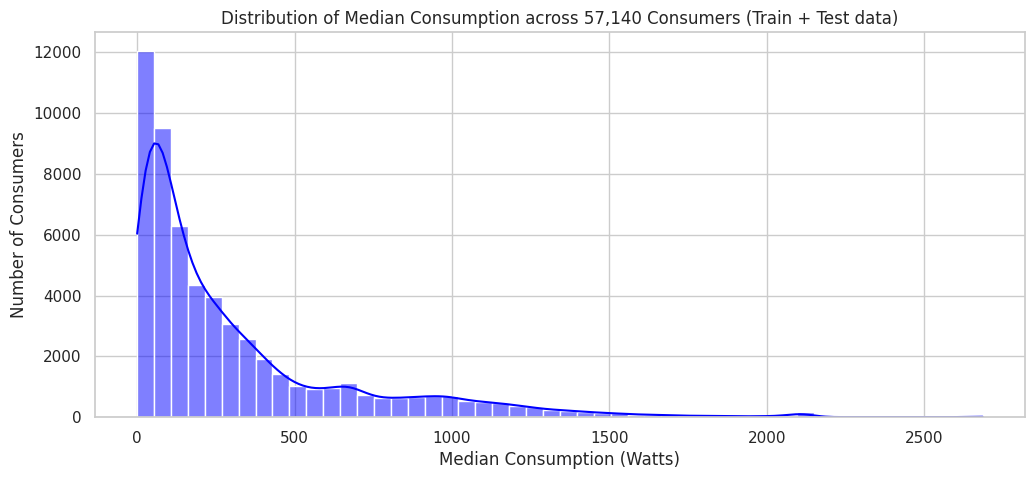

Lowest Median: 0.00
Highest Median: 2685.00
Average of Medians: 314.04


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Median Consumption for each of the consumers in train data
train_data_medians = df_normal_all.median(axis=0)

# 2. Plot the distribution of these medians
plt.figure(figsize=(12, 5))
sns.histplot(train_data_medians, bins=50, kde=True, color='blue')
plt.title("Distribution of Median Consumption across 57,140 Consumers (Train + Test data)")
plt.xlabel("Median Consumption (Watts)")
plt.ylabel("Number of Consumers")
plt.show()

print(f"Lowest Median: {train_data_medians.min():.2f}")
print(f"Highest Median: {train_data_medians.max():.2f}")
print(f"Average of Medians: {train_data_medians.mean():.2f}")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

quantiles_to_check = [0.05, 0.25, 0.50, 0.75, 0.95, 0.99]

# 1. Global Quantiles (All data points in the DataFrame combined)
global_quantiles = df_normal_all.stack().quantile(quantiles_to_check)

# 2. Quantiles per consumer (Summary of how quantiles vary across the 20,000 columns)
col_quantiles = df_normal_all.quantile(quantiles_to_check)

print("--- Global Quantiles (Entire Dataset) ---")
display(global_quantiles.to_frame(name='Watts'))

--- Global Quantiles (Entire Dataset) ---


,Watts
0.05,0.0
0.25,59.0
0.50,174.0
0.75,442.0
0.95,1276.0
0.99,2101.0


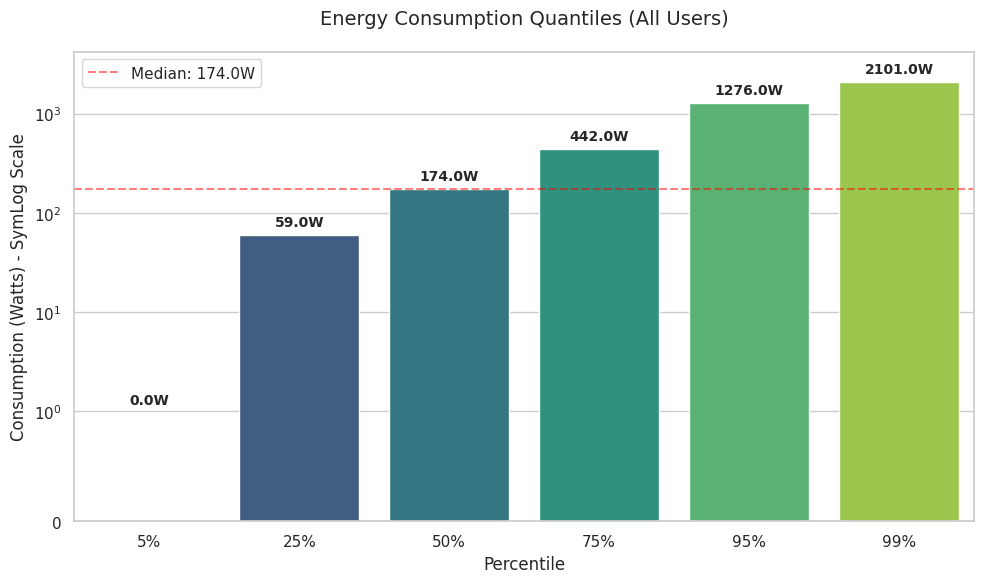

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare data with string labels
plot_data = global_quantiles.copy()
plot_data.index = [f"{int(i*100)}%" for i in plot_data.index]

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# 2. Fix the warning: Assign hue=x and legend=False
ax = sns.barplot(
    x=plot_data.index,
    y=plot_data.values,
    hue=plot_data.index,
    palette='viridis',
    legend=False
)

# 3. Use 'symlog' to handle the 0.0W value while emphasizing scale
# linthresh=1 ensures the log behavior starts very early
ax.set_yscale("symlog", linthresh=1)

plt.title("Energy Consumption Quantiles (All Users)", fontsize=14, pad=20)
plt.ylabel("Consumption (Watts) - SymLog Scale", fontsize=12)
plt.xlabel("Percentile", fontsize=12)

# Reference line for the Median
median_val = global_quantiles.loc[0.50]
plt.axhline(median_val, color='red', linestyle='--', alpha=0.5, label=f'Median: {median_val:.1f}W')

# 4. Clean annotations
for i, v in enumerate(plot_data.values):
    plt.text(i, v * 1.15 if v > 0 else 1.1, f'{v:.1f}W',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylim(0, global_quantiles.max() * 2) # Give some head room for text
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import skew, kurtosis

def calculate_distribution_stats(series, name):
    stats = {
        'Metric': [
            'Mean', 'Median', 'Standard Deviation',
            'Median Absolute Deviation (MAD)', 'Variance',
            'Skewness', 'Kurtosis', 'Min', 'Max'
        ],
        'Value': [
            series.mean(),
            series.median(),
            series.std(),
            (series - series.median()).abs().median(),
            series.var(),
            skew(series.dropna()),
            kurtosis(series.dropna()),
            series.min(),
            series.max()
        ]
    }
    return pd.DataFrame(stats).set_index('Metric')

# Let's analyze the distribution of the average grid consumption
grid_stats = calculate_distribution_stats(train_data_medians, 'Grid Mean Distribution')
print("--- Statistical Summary of Train Grid Mean ---")
display(grid_stats)

--- Statistical Summary of Train Grid Mean ---


,Value
Metric,
Mean,314.038152
Median,169.000000
Standard Deviation,375.408388
Median Absolute Deviation (MAD),128.000000
Variance,140931.457688
Skewness,2.027045
Kurtosis,4.746335
Min,0.000000
Max,2685.000000


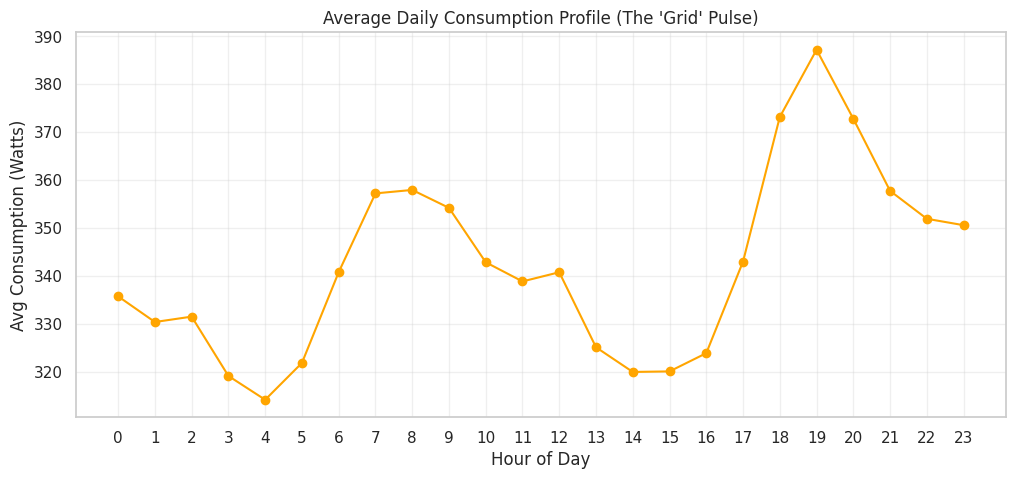

In [ ]:
# 1. Create a "Global Grid" feature by averaging all normal columns
grid_mean = df_normal_all.mean(axis=1)

# 2. Analyze Seasonality (Average Day)
# We group by the hour of the index
daily_profile = grid_mean.groupby(grid_mean.index.hour).mean()

plt.figure(figsize=(12, 5))
daily_profile.plot(kind='line', marker='o', color='orange')
# daily_profile_test.plot(kind='line', marker='o', color='blue')
plt.title("Average Daily Consumption Profile (The 'Grid' Pulse)")
plt.xlabel("Hour of Day")
plt.ylabel("Avg Consumption (Watts)")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

Text(0, 0.5, 'magnitude')

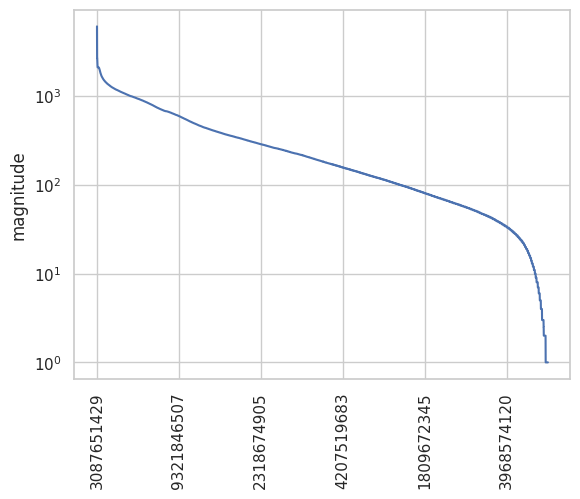

In [ ]:
df_normal_all[df_normal_all!=0].median().sort_values(ascending=False).plot(rot=90)
plt.yscale("log")

plt.ylabel("magnitude")

# Text to consider:
# we have three orders of magnitude (from $10^0$ to $10^3$) confirms that a "one size fits all" model will struggle.
# data is "top-heavy."

## Data Normalization and DataSet classes

Based on the previous analysis, We should apply Individual Standard Scaling (Or robust scaling) before the creation of the time windows, additional to that the analysis of the missing data suggest us that we should defined a window size of 336 observations (around 7 days)

Normalization:

$$z_i = \frac{x_i - \mu_i}{\sigma_i}$$

**Rational**:

| Metric | Observation | Impact on Seq2Seq Model |
|----------|----------|----------|
| Log-Scale Slope    | Smooth decay over 3 orders | orders	Need per-series scaling; cannot use a single global max.|
| Skewness    |High (Right-skewed) | Outliers in the 99th percentile will pull the mean up.|
| Q95 vs Q99    | 1285W vs 2095W |Significant "Peak" behavior. Model needs to handle spikes.|
|Lower Tail | Q25 is only 59W| Small consumers are numerous |

<br/>

#### Key Findings of the data preparation:
* **Large-Scale Data Volume**: The sliding window approach + a stride value generated a training pool of **731,392 samples** and a validation pool of **182,848 samples**, ensuring high data density for deep learning.
* **Batch Dimensions**: the `DataLoader` confirmed tensor shapes of `[Batch_size, 336, 8]` for inputs, `[Batch_size, 336, 1]` for targets and `[Batch_size, 336, 1]` for masked values, which aligns perfectly with the requirements of Seq2Seq recurrent or transformer-based models.

Note: in our case we are using a `Batch_size` of 64.

#### Insights or Next Steps
* **Sequence-to-Sequence Modeling**: The next step is to define the Encoder-Decoder model architecture, likely using LSTM or GRU layers to process the confirmed `(Batch, Window, Features)` input.
* **Memory Management**: Given the large number of samples (over 900k total), monitoring GPU memory during training will be critical, despite the efficient indexing used in the `Dataset` class.


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
# Experiment A v12 - Log-Transform before Scaling ------------------------
import numpy as np

# Apply Log-Transform before Scaling
# We use log1p (ln(1+x)) to handle zero values safely
df_log_all = np.log1p(df_normal_all)

# Now scale the LOGGED data
scaler_all = StandardScaler()
df_scaled_all = pd.DataFrame(
    scaler_all.fit_transform(df_log_all),
    index=df_normal_all.index,
    columns=df_normal_all.columns
)
# ---------------------------------------------------------------------------

# We use log1p (ln(1+x)) to handle zero values safely
df_log_holed = np.log1p(df_train_holed)
# It handles NaNs automatically per column
scaler_holed = StandardScaler()
df_scaled_holed = pd.DataFrame(
    scaler_holed.fit_transform(df_log_holed),
    index=df_train_holed.index,
    columns=df_train_holed.columns
)

print(f"Optimization complete. Using vectorized operations.")

Optimization complete. Using vectorized operations.


### Defining Sliding Window Dataset Class

The `EnergySeriesDataset`. It takes scaled DataFrames as input and implement a sliding window approach (e.g., 7 days of context) to return (input_sequence, target_sequence) pairs. The class should handle the 'holed' vs 'normal' logic and include the 'grid_mean' as an auxiliary feature.


In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class EnergySeriesDataset(Dataset):
    def __init__(self, meter_df, window_size=336, stride=48, gap_len=48):
        """
        Args:
            meter_df: Scaled DataFrame (time x meters)
            window_size: Number of 30-min intervals (default 336 = 7 days)
        """
        self.meter_data = meter_df.values.astype('float32')

        self.window_size = window_size
        self.stride = stride
        self.gap_len = gap_len
        self.num_meters = self.meter_data.shape[1]
        self.total_time = self.meter_data.shape[0]
        self.meter_names = meter_df.columns.tolist()

        # Samples per meter: total steps minus context (window) and target (window)
        self.samples_per_meter = ((self.total_time - self.window_size) // self.stride) + 1

    def __len__(self):
        return self.num_meters * self.samples_per_meter

    def __getitem__(self, idx):
        meter_idx = idx // self.samples_per_meter
        window_idx = idx % self.samples_per_meter
        time_start = window_idx * self.stride
        end_point = time_start + self.window_size

        if end_point > self.total_time:
            time_start = self.total_time - self.window_size
            end_point = self.total_time

        target_seq = self.meter_data[time_start:end_point, meter_idx]

        mask = np.ones(self.window_size, dtype='float32')

        # Seed with idx so the same sample always gets the same hole
        rng = np.random.default_rng(seed=idx)
        gap_len = rng.integers(int(self.gap_len / 2), self.gap_len + 1)
        gap_start = rng.integers(0, self.window_size - gap_len)
        mask[gap_start : gap_start + gap_len] = 0

        holed_input = target_seq.copy()
        holed_input[mask == 0] = 0.0

        x = np.column_stack([holed_input, mask])

        meter_name = self.meter_names[meter_idx]

        # we added meter name - jsut in case
        return (torch.tensor(x),
                torch.tensor(target_seq).unsqueeze(-1),
                torch.tensor(mask).unsqueeze(-1),
                meter_name)

print('EnergySeriesDataset class')

EnergySeriesDataset class


In [8]:
# wraps DataLoader creation, NaN filling, and the Subset logic into one reusable object
import pytorch_lightning as pl
from torch.utils.data import DataLoader, Subset

class EnergyDataModule(pl.LightningDataModule):
    def __init__(self, train_meter_df, val_meter_df,
                 window_size=336, gap_len=48, batch_size=512,
                 num_workers=8, train_fraction=1.0):
        super().__init__()
        self.train_meter_df = train_meter_df.fillna(0)
        self.val_meter_df = val_meter_df.fillna(0)
        self.window_size = window_size
        self.gap_len = gap_len
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.train_fraction = train_fraction

    def setup(self, stage=None):
        self.train_dataset = EnergySeriesDataset(
            self.train_meter_df,
            window_size=self.window_size, gap_len=self.gap_len
        )
        self.val_dataset = EnergySeriesDataset(
            self.val_meter_df,
            window_size=self.window_size, gap_len=self.gap_len
        )

        if self.train_fraction < 1.0:
            n = int(len(self.train_dataset) * self.train_fraction)
            indices = torch.randperm(len(self.train_dataset))[:n].tolist()
            self.train_dataset = Subset(self.train_dataset, indices)

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset, batch_size=self.batch_size,
            shuffle=True, num_workers=self.num_workers, pin_memory=True
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_dataset, batch_size=self.batch_size,
            shuffle=False, num_workers=self.num_workers, pin_memory=True
        )

In [9]:
from torch.utils.data import DataLoader 

# Instantiate the datasets
# We use the previously split dataframes (scaled version)
train_meter_df = df_scaled_all[train_ids]
val_meter_df = df_scaled_all[val_ids]

# Run this before creating your datasets
print(f"NaNs in Train Meter: {train_meter_df.isna().sum().sum()}")

# 4. Storage for Inverse Scaling
# Instead of 21,000 individual objects, you just store 3 fit scalers
# You can access specific mean/std via scaler_holed.mean_ and scaler_holed.scale_
scaling_metadata = {
    'normal': scaler_all,
    'holed': scaler_holed,
    'transform': "log1p"
}

NaNs in Train Meter: 0


# Configuring my model

In this section we are going to explore multiple strategies and check which of them works better for this problem

1. LSTM network
2. Transformers
3. RNN + GRU

After get the results, we are going to compare these model againts pre-trained models like Chronos and GluonTS

In [ ]:
import torch
import torch.nn as nn
import pytorch_lightning as pl
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512):
        super().__init__()
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.transpose(0, 1))  # (1, max_len, d_model)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class EnergyImputerModel(pl.LightningModule):
    def __init__(self, input_dim=2, d_model=256, num_layers=4, nhead=8,
                 window_size=336, lr=5e-4, weight_decay=1e-5, dropout=0.1, spectral_weight=0.1,
                 use_residual=True, steps_per_epoch=None):
        super().__init__()
        self.save_hyperparameters()

        # --- Encoder Path ---
        self.pos_encoder = PositionalEncoding(d_model, window_size)
        self.input_proj = nn.Linear(input_dim, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # --- Dual-Path Decoder ---
        combined_dim = d_model + input_dim if use_residual else d_model


        
        # Path A: Local Refinement (Convolutional)
        # Focuses on smoothing and local interpolation
        self.local_decoder = nn.Sequential(
            nn.Conv1d(combined_dim, 128, kernel_size=5, padding=2),
            nn.GELU(),
            nn.Conv1d(128, 64, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv1d(64, 1, kernel_size=3, padding=1)
        )

        # Path B: Global Feature Mapping (Linear)
        # Directly maps the Transformer's latent state to the output
        self.global_decoder = nn.Linear(combined_dim, 1)

        self.criterion = nn.HuberLoss(reduction='none', delta=0.5)
        self.use_residual = use_residual
        self.steps_per_epoch = steps_per_epoch

    def forward(self, x):
        # 1. Project and Encode
        x_proj = self.input_proj(x)                    # (B, T, d_model)
        x_pos = self.pos_encoder(x_proj)
        enc_out = self.encoder(x_pos)                  # (B, T, d_model)

        # 2. Combine with Residuals
        if self.use_residual:
            combined = torch.cat([enc_out, x], dim=-1) # (B, T, d_model + 8)
        else:
            combined = enc_out

        # 3. Path A: Convolutional (Spatial/Local)
        # Needs (B, C, T) format
        combined_T = combined.transpose(1, 2)
        local_out = self.local_decoder(combined_T)     # (B, 1, T)
        local_out = local_out.transpose(1, 2)          # (B, T, 1)

        # 4. Path B: Linear (Temporal/Global)
        global_out = self.global_decoder(combined)     # (B, T, 1)

        # 5. Summation (Ensemble of perspectives)
        return local_out + global_out

    def _compute_masked_loss(self, outputs, y_batch, mask_batch):
        """
        Experiment C: Frequency-Aware Masked Loss.
        Combines Time-Domain (Huber) and Frequency-Domain (FFT) errors.
        """
        # 1. Time-Domain Loss (Current Logic)
        # outputs/y_batch shape: (B, T, 1)
        loss = self.criterion(outputs, y_batch)
        hole_mask = 1 - mask_batch
        denominator = hole_mask.sum()

        if denominator > 0:
            time_loss = (loss * hole_mask).sum() / (denominator + 1e-6)
        else:
            time_loss = loss.mean()

        # 2. Frequency-Domain Loss (FFT)
        # We remove the last dimension for FFT: (B, T, 1) -> (B, T)
        # rfft is more efficient for real-valued time series
        y_hat_fft = torch.fft.rfft(outputs.squeeze(-1), dim=1).abs()
        y_true_fft = torch.fft.rfft(y_batch.squeeze(-1), dim=1).abs()
        
        # We use Mean Absolute Error (L1) in the frequency domain
        # This penalizes the model if the 'spikiness' doesn't match the truth
        # Calculate Absolute Difference in Frequency Domain
        spec_dist = torch.abs(y_hat_fft - y_true_fft)
        
        # v14 Weighting Mask
        # Low frequencies (indices 0-10): Fixes Magnitude/Height
        # High frequencies (indices 40+): Fixes Position/Spike Timing
        weights = torch.ones_like(spec_dist)
        weights[:, :10] *= 3.0  # Priority on Energy/Magnitude
        weights[:, 40:] *= 10.0  # Heavy penalty for Phase Shifts (timing errors)
        
        weighted_spec_loss = (spec_dist * weights).mean()   

        alpha = self.hparams.get('spectral_weight', 0.1)
        return time_loss + (alpha * weighted_spec_loss)

    def training_step(self, batch, batch_idx):
        x_batch, y_batch, mask_batch, meter_name = batch
        outputs = self(x_batch)
        loss = self._compute_masked_loss(outputs, y_batch, mask_batch)

        if torch.isnan(loss):
            return None

        self.log('train_loss', loss, on_step=True, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x_batch, y_batch, mask_batch, meter_name = batch
        outputs = self(x_batch)
        loss = self._compute_masked_loss(outputs, y_batch, mask_batch)

        if torch.isnan(loss):
            return None

        self.log('val_loss', loss, on_epoch=True, prog_bar=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.hparams.lr,
            weight_decay=self.hparams.weight_decay
        )
        
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=self.hparams.lr* 10,           # or a higher peak value
            epochs=self.trainer.max_epochs,
            steps_per_epoch=self.steps_per_epoch,
            pct_start=0.3,                    # 20% of training for warmup
            anneal_strategy='cos',
            div_factor=25,
            final_div_factor=1e4
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                # "monitor": "val_loss",
                "interval": "step",
            },
        }

In [11]:
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint, LearningRateMonitor
from pytorch_lightning.callbacks import Callback

class UpdateLRCallback(Callback):
    def __init__(self, new_lr):
        self.new_lr = new_lr
    def on_train_start(self, trainer, pl_module):
        # This hook runs AFTER the checkpoint and old optimizer state are loaded
        for optimizer in trainer.optimizers:
            for param_group in optimizer.param_groups:
                param_group['lr'] = self.new_lr
        print(f"Learning rate manually forced to {self.new_lr}")

# This will save logs to ./checkpoints/lightning_logs/
logger = TensorBoardLogger(save_dir=SAVE_DIR, name="lightning_logs")

# Previous value 336
# Now we are using 256 to take advantage of the GPU memory and compute the fft 16-bit
WINDOW_SIZE = 256

checkpoint_callback = ModelCheckpoint(
    dirpath=SAVE_DIR,
    filename='best-energy-model-{epoch:02d}-{val_loss:.4f}',
    monitor='val_loss',
    mode='min',
    save_top_k=1,        # keeps only the single best model
    save_last=True,      # also saves last.ckpt (like your latest_checkpoint.pth)
    verbose=True
)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        verbose=True,
        mode='min'
    ),
    checkpoint_callback,
    LearningRateMonitor(logging_interval='epoch'),
    # UpdateLRCallback(new_lr=1e-4)
]

dm = EnergyDataModule(
    train_meter_df=df_scaled_all[train_ids],
    val_meter_df=df_scaled_all[val_ids],
    batch_size=512,
    window_size=WINDOW_SIZE,
    gap_len=48,
    train_fraction=1,  # if you want to train on 50% of data
    num_workers=8
)

dm.setup()
# 2. Print total dataset sizes
print(f"Total training sequences: {len(dm.train_dataset)}")
print(f"Total validation sequences: {len(dm.val_dataset)}")

steps_per_epoch = len(dm.train_dataloader())
# we will use a window size of 144 (3 days) instead of 336 (7 days)
model = EnergyImputerModel(
    input_dim=2, d_model=128, window_size=WINDOW_SIZE, nhead=8,
    num_layers=4, lr=3e-4, weight_decay=1e-4, dropout=0.2,
    steps_per_epoch=steps_per_epoch, spectral_weight=0.05,
    # use_residual=False
)


trainer = pl.Trainer(
    max_epochs=100,
    accelerator='gpu',          # uses CUDA
    devices=1,
    precision='16-mixed',       # replaces your manual amp.autocast + GradScaler
    gradient_clip_val=1.0,      # replaces clip_grad_norm_(max_norm=1.0)
    callbacks=callbacks,
    logger=logger,
    default_root_dir=SAVE_DIR,
    # accumulate_grad_batches=2
)

/tmp/ipykernel_43645/169866035.py:39: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Total training sequences: 777036
Total validation sequences: 194259


### Baseline (using numerical approaches)

In [29]:
import torch
import torch.nn as nn

def calculate_baselines(dm):
    dm.setup('fit')
    val_loader = dm.val_dataloader()
    
    mse_loss = nn.MSELoss(reduction='none')       # FIX: was "mean"
    huber_loss = nn.HuberLoss(reduction='none', delta=1.0)
    
    accum = {
        'zero':    {'mse': 0, 'huber': 0},
        'ffill':   {'mse': 0, 'huber': 0},
        'interp':  {'mse': 0, 'huber': 0},
        'hist':    {'mse': 0, 'huber': 0},
    }
    total_holes = 0
    
    for x_batch, y_batch, mask_batch in val_loader:
        hole_mask = 1 - mask_batch  # 1 where hole, 0 where known
        n_holes = hole_mask.sum().item()
        total_holes += n_holes
        
        # --- 1. Zero Baseline (predict mean = 0) ---
        zero_preds = torch.zeros_like(y_batch)
        
        # --- 2. Forward Fill (use last known value before hole) ---
        ffill_preds = y_batch.clone()
        known_vals = x_batch[:, :, 0:1]  # column 0 = holed_input (0 in holes)
        mask_col = mask_batch             # 1=known, 0=hole
        for t in range(1, y_batch.shape[1]):
            ffill_preds[:, t, :] = torch.where(
                mask_col[:, t, :] == 0,
                ffill_preds[:, t-1, :],   # carry forward
                y_batch[:, t, :]           # keep true if known
            )
        
        # --- 3. Linear Interpolation (straight line across hole) ---
        interp_preds = y_batch.clone()
        B, T, _ = y_batch.shape
        for b in range(B):
            m = mask_batch[b, :, 0]  # (T,)
            in_hole = False
            start_idx = 0
            start_val = 0.0
            for t in range(T):
                if m[t] == 0 and not in_hole:
                    in_hole = True
                    start_idx = t - 1 if t > 0 else 0
                    start_val = y_batch[b, start_idx, 0].item()
                elif m[t] == 1 and in_hole:
                    in_hole = False
                    end_idx = t
                    end_val = y_batch[b, end_idx, 0].item()
                    length = end_idx - start_idx
                    for k in range(start_idx + 1, end_idx):
                        alpha = (k - start_idx) / length
                        interp_preds[b, k, 0] = start_val + alpha * (end_val - start_val)
            if in_hole:
                for k in range(start_idx + 1, T):
                    interp_preds[b, k, 0] = start_val
        
        # --- 4. Historical Daily (copy from 48 steps ago) ---
        hist_preds = torch.zeros_like(y_batch)
        hist_preds[:, 48:, :] = y_batch[:, :-48, :]
        
        # --- Calculate losses on holes only ---
        for name, preds in [('zero', zero_preds), ('ffill', ffill_preds),
                            ('interp', interp_preds), ('hist', hist_preds)]:
            m = (mse_loss(preds, y_batch) * hole_mask).sum().item()
            h = (huber_loss(preds, y_batch) * hole_mask).sum().item()
            accum[name]['mse'] += m
            accum[name]['huber'] += h
    
    print(f"{'Baseline':<25} {'MSE':>8} {'RMSE':>8} {'Huber':>8}")
    print("-" * 55)
    for name, vals in accum.items():
        mse_val = vals['mse'] / total_holes
        rmse_val = mse_val ** 0.5
        huber_val = vals['huber'] / total_holes
        print(f"{name:<25} {mse_val:>8.4f} {rmse_val:>8.4f} {huber_val:>8.4f}")

calculate_baselines(dm)

Baseline                       MSE     RMSE    Huber
-------------------------------------------------------
zero                        0.9460   0.9726   0.3500
ffill                       1.5707   1.2533   0.4990
interp                      1.2274   1.1079   0.4126
hist                        1.0046   1.0023   0.3356


### Training loop

In [ ]:
# Monitoring the training process
# Load the TensorBoard notebook extension
%load_ext tensorboard

# Start TensorBoard pointing to the directory where logs are saved
%tensorboard --logdir ./checkpoints/lightning_logs/

In [16]:
import os

# Define the path you want to resume from
ckpt_path = f'{SAVE_DIR}last.ckpt'

# If the file exists, Lightning will resume. If not, it trains from scratch.
if os.path.exists(ckpt_path):
    print(f"Found checkpoint at {ckpt_path}. Resuming training...")
    trainer.fit(model, datamodule=dm, ckpt_path=ckpt_path)
else:
    print("No checkpoint found. Starting training from scratch...")
    trainer.fit(model, datamodule=dm)

Restoring states from the checkpoint path at ./checkpoints/last.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name           | Type               | Params | Mode | FLOPs
---------------------------------------------------------------------
0 | pos_encoder    | PositionalEncoding | 0      | eval | 0    
1 | input_proj     | Linear             | 384    | eval | 0    
2 | encoder        | TransformerEncoder | 793 K  | eval | 0    
3 | local_decoder  | Sequential         | 108 K  | eval | 0    
4 | global_decoder | Linear             | 131    | eval | 0    
5 | criterion      | HuberLoss          | 0      | eval | 0    
---------------------------------------------------------------------
901 K     Trainable params
0         Non-trainable params
901 K     Total params
3.607     Total estimated model params size (MB)
0         Modules in train mode
52        Modules in eval mode
0         Total Flops
Restored all states from the checkpoint at ./checkpoints/last.ckpt


Found checkpoint at ./checkpoints/last.ckpt. Resuming training...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/srsanti/projects/ml_projects/seq2seq_electric_curves_reconstruction/.venv/lib/python3.12/site-packages/pytorch_lightning/loops/fit_loop.py:534: Found 53 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 44, global step 68310: 'val_loss' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 45, global step 69828: 'val_loss' was not in top 1

Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

### Using trained model

In [17]:
# save model
torch.save(model, SAVE_DIR + 'model.pth')

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_id=checkpoint_callback.best_model_path.split('/')[-1]
print(f"Loading model from {model_id}")
# Lightning checkpoints store hyperparameters + weights together
model = EnergyImputerModel.load_from_checkpoint(
    f'{SAVE_DIR}{model_id}'
)
model.eval()

Loading model from best-energy-model-epoch=43-val_loss=0.7102.ckpt


/tmp/ipykernel_43645/169866035.py:39: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


EnergyImputerModel(
  (pos_encoder): PositionalEncoding()
  (input_proj): Linear(in_features=2, out_features=128, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (local_decoder): Sequential(
    (0): Conv1d(130, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): GELU(approximate='none')
    (2): Conv1d(128, 64, kernel_si

Validation imputation metrics (holes, Watts):
  micro_mae: 80.19189738782826
  macro_mae: 80.0311297340286
  micro_rmse: 168.79071299067627
  macro_rmse: 112.97462702154593
  macro_mae_trimmed_5pct: 67.93638846097542
  median_mae: 49.90252685546875
  std_mae: 93.29547286466679
  min_mae: 0.00022995212930254638
  max_mae: 1722.6685791015625
  p25_mae: 21.956348419189453
  p75_mae: 102.8535270690918
  p90_mae: 190.50859069824222
  p95_mae: 261.888168334961
  n_windows: 194259
  n_hole_timesteps: 6994211


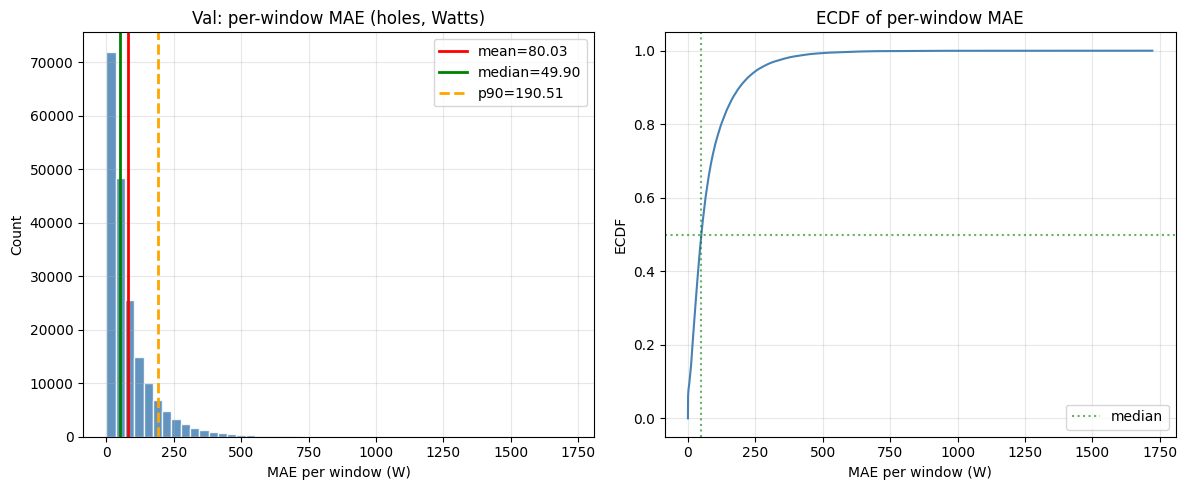

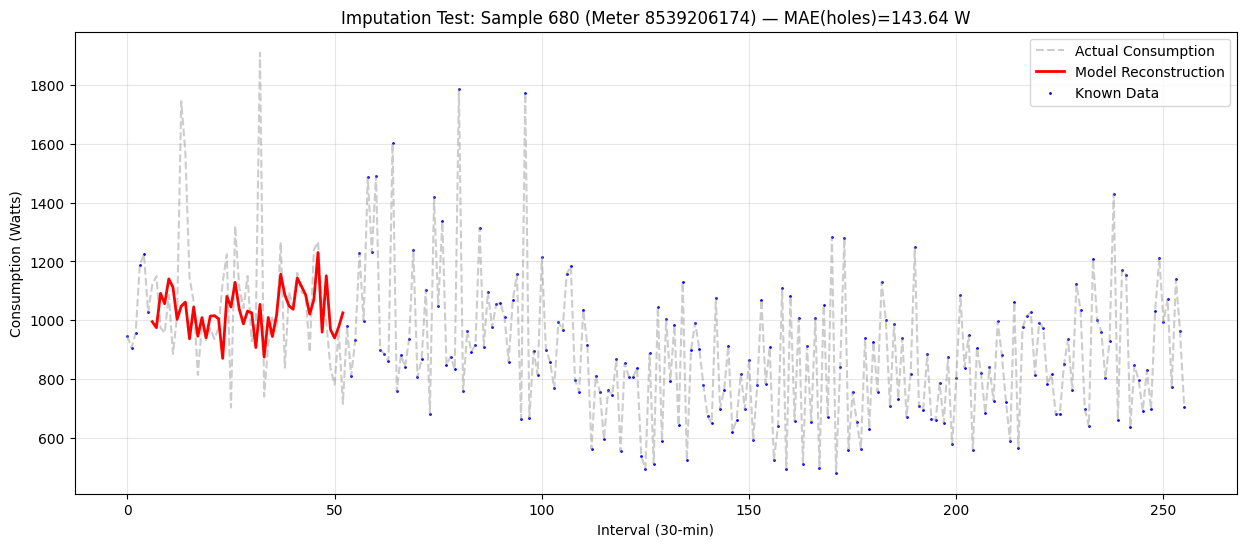

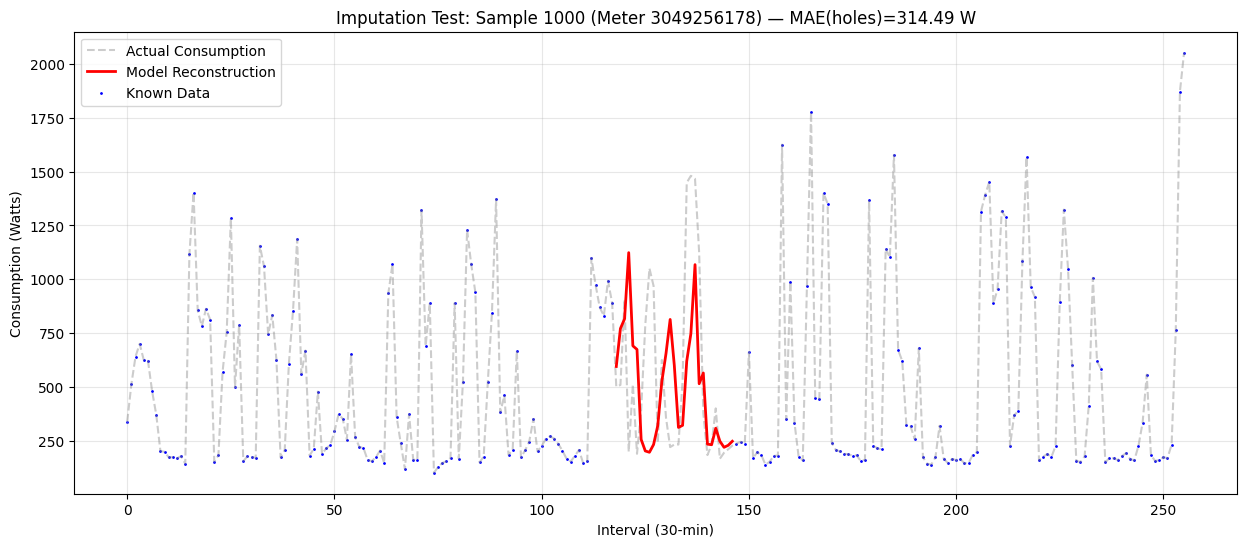

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy import stats as scipy_stats

def inverse_scale_single_meter(data, col_idx, scaler_obj):
    """Inverse StandardScaler for one column + expm1 (no full n_features matrix)."""
    z = np.asarray(data, dtype=np.float64).reshape(-1)
    mean = scaler_obj.mean_[col_idx]
    scale = scaler_obj.scale_[col_idx]
    log1p_vals = z * scale + mean
    return torch.tensor(np.expm1(log1p_vals), dtype=torch.float32)


def evaluate_imputation_val(model, val_dataloader, scaler, all_columns, device):
    """
    Full val pass: hole-only MAE/RMSE in Watts (micro vs macro) and per-window MAE for distribution plots.
    """
    model = model.to(device)
    model.eval()
    per_window_mae = []
    per_window_rmse = []
    sum_abs = 0.0
    sum_sq = 0.0
    n_hole_steps = 0

    with torch.no_grad():
        for batch in val_dataloader:
            x_batch, y_batch, mask_batch, meter_name = batch
            x_batch = x_batch.to(device)
            preds = model(x_batch).cpu()
            y_batch = y_batch.cpu()
            mask_batch = mask_batch.cpu()
            B = x_batch.size(0)
            for b in range(B):
                name = meter_name[b] if isinstance(meter_name, (list, tuple)) else meter_name
                col_idx = all_columns.get_loc(name)
                pred_np = preds[b].squeeze(-1).numpy()
                y_np = y_batch[b].squeeze(-1).numpy()
                pred_w = inverse_scale_single_meter(pred_np, col_idx, scaler)
                y_w = inverse_scale_single_meter(y_np, col_idx, scaler)
                mask_b = mask_batch[b].squeeze(-1).bool()
                hole_mask = ~mask_b
                if not hole_mask.any():
                    continue
                err = pred_w[hole_mask].float() - y_w[hole_mask].float()
                ae = err.abs()
                mae_b = ae.mean().item()
                rmse_b = torch.sqrt((err ** 2).mean()).item()
                per_window_mae.append(mae_b)
                per_window_rmse.append(rmse_b)
                sum_abs += ae.sum().item()
                sum_sq += (err ** 2).sum().item()
                n_hole_steps += int(ae.numel())

    mae_arr = np.asarray(per_window_mae, dtype=np.float64)
    rmse_arr = np.asarray(per_window_rmse, dtype=np.float64)

    if len(mae_arr) == 0:
        stats = {
            "micro_mae": float("nan"),
            "macro_mae": float("nan"),
            "micro_rmse": float("nan"),
            "macro_rmse": float("nan"),
            "macro_mae_trimmed_5pct": float("nan"),
            "n_windows": 0,
            "n_hole_timesteps": n_hole_steps,
        }
        return stats, mae_arr

    stats = {
        "micro_mae": sum_abs / max(n_hole_steps, 1),
        "macro_mae": float(mae_arr.mean()),
        "micro_rmse": float(np.sqrt(sum_sq / max(n_hole_steps, 1))),
        "macro_rmse": float(rmse_arr.mean()),
        "macro_mae_trimmed_5pct": float(scipy_stats.trim_mean(mae_arr, proportiontocut=0.05)),
        "median_mae": float(np.median(mae_arr)),
        "std_mae": float(mae_arr.std(ddof=0)),
        "min_mae": float(mae_arr.min()),
        "max_mae": float(mae_arr.max()),
        "p25_mae": float(np.percentile(mae_arr, 25)),
        "p75_mae": float(np.percentile(mae_arr, 75)),
        "p90_mae": float(np.percentile(mae_arr, 90)),
        "p95_mae": float(np.percentile(mae_arr, 95)),
        "n_windows": int(len(mae_arr)),
        "n_hole_timesteps": n_hole_steps,
    }
    return stats, mae_arr

# ECDF: Empirical cumulative distribution function
def plot_per_window_mae_distribution(per_window_maes, title="", log_x=False, figsize=(12, 5)):
    """Histogram + ECDF; vertical lines for mean, median, p90 (handles heavy tails via log_x)."""
    m = np.asarray(per_window_maes, dtype=np.float64)
    if m.size == 0:
        print("No per-window MAE values to plot.")
        return
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    ax0, ax1 = axes
    mean_v, med_v, p90_v = float(m.mean()), float(np.median(m)), float(np.percentile(m, 90))

    if log_x:
        m_plot = np.clip(m, 1e-12, None)
        ax0.hist(m_plot, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
        ax0.set_xscale("log")
        ax0.set_xlabel("MAE per window (W, log scale)")
    else:
        ax0.hist(m, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
        ax0.set_xlabel("MAE per window (W)")

    ax0.axvline(mean_v, color="red", linewidth=2, label=f"mean={mean_v:.2f}")
    ax0.axvline(med_v, color="green", linewidth=2, label=f"median={med_v:.2f}")
    ax0.axvline(p90_v, color="orange", linestyle="--", linewidth=2, label=f"p90={p90_v:.2f}")
    ax0.set_ylabel("Count")
    ax0.legend()
    ax0.grid(True, alpha=0.3)
    ax0.set_title(title or "Per-window MAE (holes, Watts)")

    ms = np.sort(m)
    y_ecdf = np.arange(1, len(ms) + 1) / len(ms)
    ax1.plot(ms, y_ecdf, color="steelblue", linewidth=1.5)
    ax1.axhline(0.5, color="green", linestyle=":", alpha=0.6)
    ax1.axvline(med_v, color="green", linestyle=":", alpha=0.6, label="median")
    ax1.set_xlabel("MAE per window (W)")
    ax1.set_ylabel("ECDF")
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.set_title("ECDF of per-window MAE")
    plt.tight_layout()
    plt.show()


def plot_reconstruction_test_v12(model, dataset, device, scaler, all_columns, sample_idx=500):
    model = model.to(device)
    model.eval()

    with torch.no_grad():
        x, y, mask, meter_name = dataset[sample_idx]
        global_col_idx = all_columns.get_loc(meter_name)
        x_batch = x.unsqueeze(0).to(device)

        pred = model(x_batch).cpu().squeeze().numpy()
        y_true = y.squeeze().numpy()

        pred_final = inverse_scale_single_meter(pred, global_col_idx, scaler)
        y_true_final = inverse_scale_single_meter(y_true, global_col_idx, scaler)

        mask_bool = mask.squeeze().bool()
        hole_mask = ~mask_bool
        if hole_mask.any():
            mae_holes = torch.mean(
                torch.abs(pred_final[hole_mask].float() - y_true_final[hole_mask].float())
            ).item()
        else:
            mae_holes = float("nan")

        plt.figure(figsize=(15, 6))
        plt.plot(y_true_final, label="Actual Consumption", color="gray", alpha=0.4, linestyle="--")
        hole_indices = torch.where(~mask_bool)[0]
        plt.plot(hole_indices, pred_final[hole_indices], label="Model Reconstruction", color="red", linewidth=2)
        known_indices = torch.where(mask_bool)[0]
        plt.scatter(known_indices, y_true_final[known_indices], s=1, color="blue", label="Known Data")
        plt.title(
            f"Imputation Test: Sample {sample_idx} (Meter {meter_name}) — MAE(holes)={mae_holes:.2f} W"
        )
        plt.xlabel("Interval (30-min)")
        plt.ylabel("Consumption (Watts)")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()


dm.setup()
val_dataset = dm.val_dataset

val_stats, val_mae_per_window = evaluate_imputation_val(
    model, dm.val_dataloader(), scaler_all, df_scaled_all.columns, device
)
print("Validation imputation metrics (holes, Watts):")
for k, v in val_stats.items():
    print(f"  {k}: {v}")

plot_per_window_mae_distribution(val_mae_per_window, title="Val: per-window MAE (holes, Watts)")

plot_reconstruction_test_v12(
    model, val_dataset, device, scaler_all, sample_idx=680, all_columns=df_scaled_all.columns
)
plot_reconstruction_test_v12(
    model, val_dataset, device, scaler_all, sample_idx=1000, all_columns=df_scaled_all.columns
)